In [1]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from pyfrechet.metric_spaces import MetricData, Sphere
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pyfrechet.metric_spaces import MetricData, Sphere
import cloudpickle
import base64
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from joblib import Parallel, delayed
from scipy.stats import vonmises_fisher, vonmises_line

INFO: Using numpy backend


## Functions

In [557]:
def pb_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'kappa', 'OOB_quantile', 'i_cov', 'ii_cov', 'iii_cov', 'iv_cov'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_sphere'), 'results')):
        if (file.endswith('.npy')):# and file.split('_')[3][5:] == '100'):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_sphere'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            print(result)
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'kappa': file.split('_')[3][5:],
            'i_cov': [result['i_cov']],
            'ii_cov': [result['ii_cov']],
            'iii_cov': [result['iii_cov']],
            'iv_cov': [result['iv_cov']],
            'OOB_quantile': [result['OOB_quantile']],
            'extreme_5':  [result['extreme_5']],
            'extreme_15': [result['extreme_15']],
            'extreme_25': [result['extreme_25']],
            'middle_5':   [result['middle_5']],
            'middle_15':  [result['middle_5']],
            'middle_25':  [result['middle_5']]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['kappa'] = coverage_df.kappa.astype('category')
    return coverage_df


# Function defining the regression mean m_0(theta) on S^2
def m_0(theta, mu):
    """
    Compute the regression mean on S^2.
    
    Parameters:
    theta : array-like
        Angles in [0, 2pi) that parameterize the great circle.
    mu : array-like, shape (2,)
        A unit vector defining the orientation of the great circle.
    
    Returns:
    array, shape (n, 3)
        The mean directions on S^2.
    """
    theta = np.asarray(theta)
    mu = np.asarray(mu)
    assert mu.shape == (2,) and np.isclose(np.linalg.norm(mu), 1), "mu must be a unit vector in R^2"
    
    x1 = np.cos(theta)
    x2 = np.sin(theta) * mu[0]
    x3 = np.sin(theta) * mu[1]
    
    return np.column_stack((x1, x2, x3))

# Function to generate vMF samples
def simulate_data(kappa, mu, theta_samples):
    """
    Generate samples from the von Mises-Fisher distribution on S^2.
    
    Parameters:
    sample_size : int
        Number of samples to generate.
    kappa : float
        Concentration parameter of the vMF distribution.
    mu : array-like, shape (2,)
        The unit vector defining the great circle.
    
    Returns:
    dict
        A dictionary containing input angles and generated samples.
    """
    mean_directions = m_0(theta_samples, mu)  # Compute means on S^2
    
    samples = [vonmises_fisher(mean, kappa).rvs() for mean in mean_directions]
    
    return theta_samples, np.array(samples)

# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
kappa_values = [50, 200]  # Concentration parameters
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

Prediction balls

In [558]:
# Define confidence levels
M = Sphere(2)
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
pb_coverage_df=pb_coverage_results()
pb_coverage_df.head()

0
{'i_cov': array([[1., 0., 0.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 0., 0.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 0.],
       [1., 1., 1.],
       [1., 1., 0.],
       [1., 1., 0.],
       [1., 1., 1.],
       [1., 1., 0.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 0., 0.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
 

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov,extreme_5,extreme_15,extreme_25,middle_5,middle_15,middle_25
0,7,50,200,"[0.8705382953811639, 0.3250671847247314, 0.267...","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.946, 0.918]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ..."
1,12,50,50,"[0.8320762631128114, 0.4319226673663229, 0.360...","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[1.0, 0.948, 0.894]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.994, 0.95]","{'kappa_50': {'50': [0.23626761769525917], '10...","{'kappa_50': {'50': [0.15959418216664117], '10...","{'kappa_50': {'50': [0.13783196849890827], '10...","{'kappa_50': {'50': [0.0767783014598494], '100...","{'kappa_50': {'50': [0.0767783014598494], '100...","{'kappa_50': {'50': [0.0767783014598494], '100..."
2,22,100,200,"[0.47486662798960766, 0.25283859198084147, 0.1...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.972, 0.908]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 0.952]","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ..."
3,11,500,50,"[0.47580610358693287, 0.36134116122932736, 0.3...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.954, 0.9]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.95, 0.906]","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ..."
4,13,500,200,"[0.23420644535502197, 0.1802812443844742, 0.16...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.936, 0.872]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.994, 0.944, 0.902]","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ...","{'kappa_50': {'50': [], '100': [], '200': [], ..."


In [559]:
pb_coverage_df['kappa'][0]

'200'

# TYPE I

In [4]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_i_coverage(pb_coverage_df, sample_sizes, kappa_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    pb_diccionario_i = {
    'kappa_50': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    for N in sample_sizes:
        for kappa in kappa_values:
            means = []
            pb_coverage_df_N_kappa = pb_coverage_df[(pb_coverage_df['kappa'] == str(kappa)) 
            & (pb_coverage_df['train_size'] == N)
            ]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in pb_coverage_df['i_cov']
                row_data = pb_coverage_df_N_kappa['i_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                row_mean = row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                means.append(row_mean)

            pb_diccionario_i['kappa_' + str(kappa)][str(N)] = means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return pb_diccionario_i

sample_sizes = [50, 100, 200, 500]  # Sample sizes
kappa_values = [50, 200]  # Concentration parameters

pb_diccionario_i = calculate_type_i_coverage(pb_coverage_df = pb_coverage_df, sample_sizes = sample_sizes, kappa_values = kappa_values)
pb_diccionario_i

{'kappa_50': {'50': [array([0.986, 0.958, 0.902]),
   array([0.986, 0.942, 0.878]),
   array([0.984, 0.93 , 0.884]),
   array([0.992, 0.944, 0.878]),
   array([0.978, 0.942, 0.864]),
   array([0.992, 0.956, 0.908]),
   array([0.982, 0.942, 0.9  ]),
   array([0.99 , 0.946, 0.87 ]),
   array([0.992, 0.952, 0.872]),
   array([0.982, 0.94 , 0.888]),
   array([0.978, 0.956, 0.888]),
   array([0.982, 0.938, 0.874]),
   array([0.99 , 0.958, 0.91 ]),
   array([0.992, 0.958, 0.904]),
   array([0.99 , 0.96 , 0.906]),
   array([0.984, 0.946, 0.898]),
   array([0.974, 0.924, 0.86 ]),
   array([0.974, 0.93 , 0.868]),
   array([0.986, 0.954, 0.894]),
   array([0.982, 0.944, 0.908]),
   array([0.988, 0.946, 0.886]),
   array([0.982, 0.942, 0.892]),
   array([0.99 , 0.94 , 0.884]),
   array([0.98 , 0.924, 0.858]),
   array([0.994, 0.95 , 0.898]),
   array([0.99, 0.94, 0.89]),
   array([0.984, 0.928, 0.894]),
   array([0.99 , 0.946, 0.882]),
   array([0.976, 0.922, 0.848]),
   array([0.986, 0.956, 0.88

Prediction balls

In [5]:
# Prepare data for the DataFrame
rows = []
index = []

for kappa in [50, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario_i[f'kappa_{kappa}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario_i[f'kappa_{kappa}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
df

Significance Level          0.01          0.05           0.1
kappa N                                                     
50    50            98.52 (0.54)  94.30 (1.01)  88.35 (1.57)
      100           98.12 (0.57)  94.17 (1.02)  89.47 (1.30)
      200           98.55 (0.46)  94.59 (0.83)  89.79 (1.29)
      500           98.73 (0.52)  94.78 (1.01)  89.72 (1.48)
200   50            98.43 (0.51)  94.44 (0.99)  88.36 (1.24)
      100           98.34 (0.57)  94.16 (0.80)  89.08 (1.32)
      200           98.58 (0.48)  94.51 (0.93)  89.36 (1.27)
      500           98.74 (0.52)  94.46 (1.22)  89.56 (1.59)

In [6]:
import pandas as pd
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Apply formatting to all cells
df = df.applymap(format_cell)

latex = df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:typeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56410/2912561022.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(format_cell)


In [7]:
print(latex)

\begin{table}
\caption{Type I error}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
kappa & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{50}} & \textbf{50} & 98.52 (0.54) & 94.30 (1.01) & 88.35 (1.57) \\
\textbf{} & \textbf{100} & 98.12 (0.57) & 94.17 (1.02) & 89.47 (1.30) \\
\textbf{} & \textbf{200} & 98.55 (0.46) & 94.59 (0.83) & 89.79 (1.29) \\
\textbf{} & \textbf{500} & 98.73 (0.52) & 94.78 (1.01) & 89.72 (1.48) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{200}} & \textbf{50} & 98.43 (0.51) & 94.44 (0.99) & 88.36 (1.24) \\
\textbf{} & \textbf{100} & 98.34 (0.57) & 94.16 (0.80) & 89.08 (1.32) \\
\textbf{} & \textbf{200} & 98.58 (0.48) & 94.51 (0.93) & 89.36 (1.27) \\
\textbf{} & \textbf{500} & 98.74 (0.52) & 94.46 (1.22) & 89.56 (1.59) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



# TYPE II

### KAPPA 50

In [8]:
ii_pb_coverage_df_kappa_50_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
ii_pb_coverage_df_kappa_50_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
ii_pb_coverage_df_kappa_50_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()

ii_pb_coverage_df_kappa_50_alpha_01['ii_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['ii_cov'].apply(lambda x: x[0])
ii_pb_coverage_df_kappa_50_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[0])

ii_pb_coverage_df_kappa_50_alpha_05['ii_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['ii_cov'].apply(lambda x: x[1])
ii_pb_coverage_df_kappa_50_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[1])

ii_pb_coverage_df_kappa_50_alpha_1['ii_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['ii_cov'].apply(lambda x: x[2])
ii_pb_coverage_df_kappa_50_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_kappa_50_alpha_01.head()
ii_pb_coverage_df_kappa_50_alpha_05.head()
ii_pb_coverage_df_kappa_50_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
0,470,50,50,0.396830,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.920,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.994, 0.964]"
4,49,100,50,0.390880,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.940,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.988, 0.962]"
5,152,50,50,0.430612,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.954,"[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.968, 0.914]"
8,17,100,50,0.324838,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...",0.836,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.99, 0.904, 0.802]"
11,380,50,50,0.364252,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.854,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.956, 0.942]"


In [9]:
ii_pb_coverage_df_kappa_200_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
ii_pb_coverage_df_kappa_200_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
ii_pb_coverage_df_kappa_200_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()

ii_pb_coverage_df_kappa_200_alpha_01['ii_cov'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['ii_cov'].apply(lambda x: x[0])
ii_pb_coverage_df_kappa_200_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[0])

ii_pb_coverage_df_kappa_200_alpha_05['ii_cov'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['ii_cov'].apply(lambda x: x[1])
ii_pb_coverage_df_kappa_200_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[1])

ii_pb_coverage_df_kappa_200_alpha_1['ii_cov'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['ii_cov'].apply(lambda x: x[2])
ii_pb_coverage_df_kappa_200_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_kappa_200_alpha_01.head()
ii_pb_coverage_df_kappa_200_alpha_05.head()
ii_pb_coverage_df_kappa_200_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
1,403,50,200,0.241634,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.864,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 0.994]"
2,302,50,200,0.262673,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.874,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]"
3,314,200,200,0.189467,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.932,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.978, 0.97]"
6,68,200,200,0.179076,"[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.896,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.932, 0.858]"
7,485,500,200,0.169254,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.898,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.922, 0.86]"


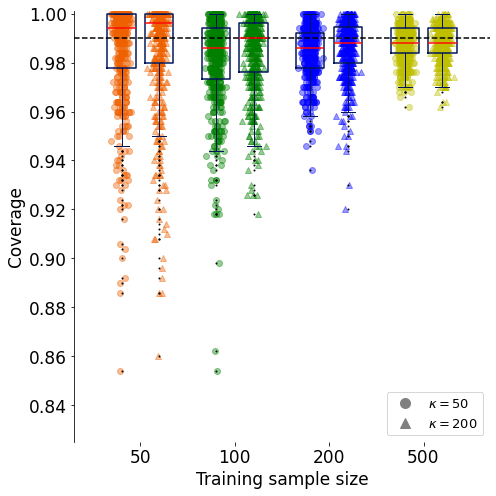

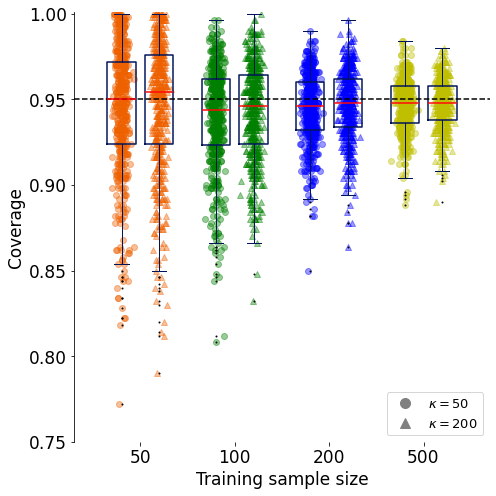

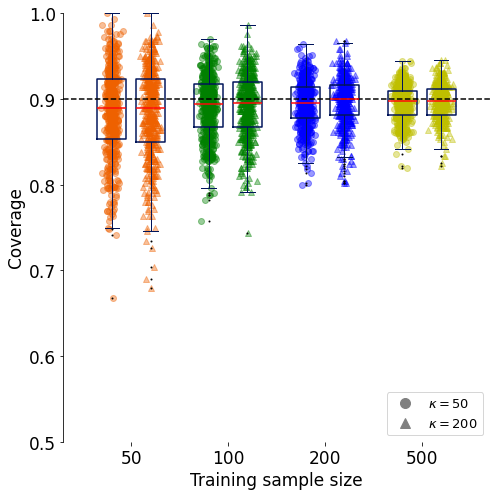

In [10]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for kappa_50_data, kappa_200_data, alpha_level in zip(
    [ii_pb_coverage_df_kappa_50_alpha_01, ii_pb_coverage_df_kappa_50_alpha_05, ii_pb_coverage_df_kappa_50_alpha_1], 
    [ii_pb_coverage_df_kappa_200_alpha_01, ii_pb_coverage_df_kappa_200_alpha_05, ii_pb_coverage_df_kappa_200_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    kappa_50_boxplot_data = [kappa_50_data[kappa_50_data['train_size'] == size]['ii_cov'].values for size in train_sizes]
    kappa_200_boxplot_data = [kappa_200_data[kappa_200_data['train_size'] == size]['ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_kappa_50 = np.array(range(len(train_sizes))) - 0.2
    positions_kappa_200 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(kappa_50_boxplot_data, positions=positions_kappa_50, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(kappa_200_boxplot_data, positions=positions_kappa_200, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_kappa_50 = ['#ee6100', 'g', 'b', 'y']
    palette_kappa_200 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_kappa_50 = np.random.normal(positions_kappa_50[i], 0.04, len(kappa_50_boxplot_data[i]))
        xs_kappa_200 = np.random.normal(positions_kappa_200[i], 0.04, len(kappa_200_boxplot_data[i]))

        ax.scatter(xs_kappa_50, kappa_50_boxplot_data[i], alpha=0.4, color=palette_kappa_50[i], label='Prediction balls')
        ax.scatter(xs_kappa_200, kappa_200_boxplot_data[i], alpha=0.4, color=palette_kappa_200[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$\kappa = 50$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$\kappa = 200$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_sphere/pb_sphere_kappa_50_200_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

In [11]:
ii_pb_coverage_df_alpha_01 = pb_coverage_df.copy()
ii_pb_coverage_df_alpha_05 = pb_coverage_df.copy()
ii_pb_coverage_df_alpha_1  = pb_coverage_df.copy()

ii_pb_coverage_df_alpha_01['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[0])
ii_pb_coverage_df_alpha_05['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[1])
ii_pb_coverage_df_alpha_1['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_alpha_01.head()
ii_pb_coverage_df_alpha_05.head()
ii_pb_coverage_df_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
0,470,50,50,0.396830,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.98, 0.92]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.994, 0.964]"
1,403,50,200,0.241634,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.882, 0.864]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 0.994]"
2,302,50,200,0.262673,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.95, 0.874]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]"
3,314,200,200,0.189467,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.946, 0.932]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.978, 0.97]"
4,49,100,50,0.390880,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.98, 0.94]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.988, 0.962]"


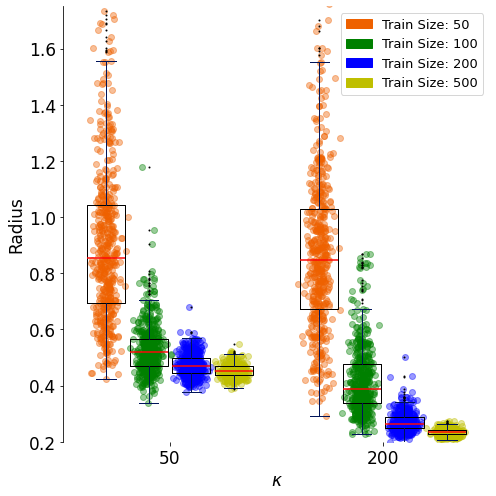

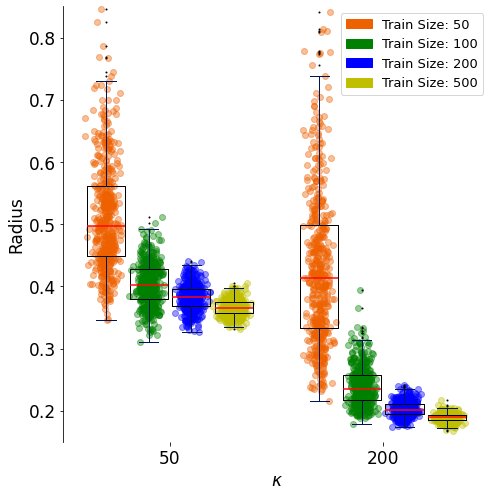

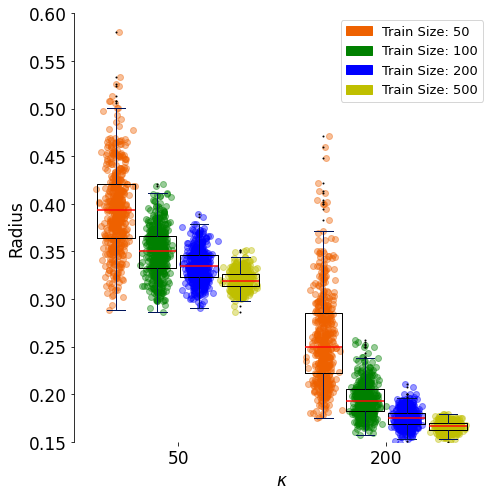

In [13]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_pb_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_pb_coverage_df_alpha_05
    else:
        coverage_df = ii_pb_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    kappas = coverage_df['kappa'].unique()
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['kappa'] == kappa) & (coverage_df['train_size'] == N), 'OOB_quantile']
            for N in train_sizes]
        for kappa in kappas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j])


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(kappas))],
        labels=kappas
    )
    ax.set_xlim(0, len(kappas) * (len(train_sizes) + 1))
    if alpha_level == 0.01:
        ax.set_ylim(0.2, 1.75)
    elif alpha_level == 0.05:
        ax.set_ylim(0.15, 0.85)
    else:
        ax.set_ylim(0.15, 0.6)
        
    ax.set_xlabel(r'$\kappa$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'simulations_sphere/pb_sphere_radius_vs_kappa' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [77]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_iii_coverage(pb_coverage_df, sample_sizes, kappa_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    pb_diccionario_iii = {
    'kappa_50': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    for N in sample_sizes:
        for kappa in kappa_values:
            means = []
            pb_coverage_df_N_kappa = pb_coverage_df[(pb_coverage_df['kappa'] == str(kappa)) 
            & (pb_coverage_df['train_size'] == N)
            ]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in pb_coverage_df['i_cov']
                row_data = pb_coverage_df_N_kappa['iii_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                row_mean = row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                means.append(row_mean)

            pb_diccionario_iii['kappa_' + str(kappa)][str(N)] = means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return pb_diccionario_iii

sample_sizes = [50, 100, 200, 500]  # Sample sizes
kappa_values = [50, 200]  # Concentration parameters

pb_diccionario_iii = calculate_type_iii_coverage(pb_coverage_df = pb_coverage_df, sample_sizes = sample_sizes, kappa_values = kappa_values)
pb_diccionario_iii

{'kappa_50': {'50': [array([1.   , 0.986, 0.952]),
   array([0.998, 0.982, 0.94 ]),
   array([0.998, 0.992, 0.962]),
   array([1.   , 0.99 , 0.958]),
   array([0.998, 0.984, 0.936]),
   array([0.998, 0.984, 0.942]),
   array([1.   , 0.986, 0.944]),
   array([1.   , 0.988, 0.942]),
   array([0.998, 0.988, 0.942]),
   array([1.   , 0.988, 0.942]),
   array([0.996, 0.988, 0.95 ]),
   array([1.   , 0.986, 0.94 ]),
   array([0.998, 0.976, 0.946]),
   array([0.998, 0.984, 0.952]),
   array([0.998, 0.982, 0.95 ]),
   array([1.   , 0.996, 0.952]),
   array([1.   , 0.99 , 0.928]),
   array([1.   , 0.99 , 0.942]),
   array([1.   , 0.984, 0.938]),
   array([1.   , 0.968, 0.912]),
   array([0.998, 0.982, 0.932]),
   array([1.   , 0.998, 0.95 ]),
   array([1.   , 0.99 , 0.952]),
   array([0.998, 0.988, 0.954]),
   array([1.   , 0.986, 0.952]),
   array([0.998, 0.988, 0.956]),
   array([1.   , 0.988, 0.936]),
   array([1.   , 0.984, 0.952]),
   array([0.998, 0.986, 0.942]),
   array([1.   , 0.99 , 0

In [78]:
# Prepare data for the DataFrame
rows = []
index = []

for kappa in [50, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario_iii[f'kappa_{kappa}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario_iii[f'kappa_{kappa}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
pb_df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
pb_df_iii

Significance Level           0.01          0.05           0.1
kappa N                                                      
50    50             99.92 (0.11)  98.66 (0.54)  94.60 (1.12)
      100            99.26 (0.33)  96.24 (0.71)  91.90 (1.12)
      200            98.93 (0.46)  95.25 (1.03)  90.48 (1.41)
      500            99.03 (0.46)  95.42 (1.14)  90.58 (1.58)
200   50            100.00 (0.00)  99.78 (0.18)  97.60 (0.72)
      100            99.94 (0.11)  98.48 (0.60)  94.80 (1.17)
      200            99.62 (0.26)  96.54 (0.73)  92.06 (1.16)
      500            99.01 (0.45)  95.26 (0.75)  90.44 (1.17)

In [79]:
# Apply formatting to all cells
pb_latex_iii= pb_df_iii.applymap(format_cell)

pb_latex_iii = pb_latex_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type I error coverage for differentvalues of $\sigma$ and sample sizes', label='tab:typeIerrorcoverage')
print(pb_latex_iii)

\begin{table}
\caption{Type I error coverage for differentvalues of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
kappa & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{50}} & \textbf{50} & 99.92 (0.11) & 98.66 (0.54) & 94.60 (1.12) \\
\textbf{} & \textbf{100} & 99.26 (0.33) & 96.24 (0.71) & 91.90 (1.12) \\
\textbf{} & \textbf{200} & 98.93 (0.46) & 95.25 (1.03) & 90.48 (1.41) \\
\textbf{} & \textbf{500} & 99.03 (0.46) & 95.42 (1.14) & 90.58 (1.58) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{200}} & \textbf{50} & 100.00 (0.00) & 99.78 (0.18) & 97.60 (0.72) \\
\textbf{} & \textbf{100} & 99.94 (0.11) & 98.48 (0.60) & 94.80 (1.17) \\
\textbf{} & \textbf{200} & 99.62 (0.26) & 96.54 (0.73) & 92.06 (1.16) \\
\textbf{} & \textbf{500} & 99.01 (0.45) & 95.26 (0.75) & 90.44 (1.17) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_92510/2774234259.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pb_latex_iii= pb_df_iii.applymap(format_cell)


# Type IV

### KAPPA 50

In [80]:
iv_pb_coverage_df_kappa_50_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
iv_pb_coverage_df_kappa_50_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
iv_pb_coverage_df_kappa_50_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()

iv_pb_coverage_df_kappa_50_alpha_01['iv_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['iv_cov'].apply(lambda x: x[0])
iv_pb_coverage_df_kappa_50_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[0])

iv_pb_coverage_df_kappa_50_alpha_05['iv_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['iv_cov'].apply(lambda x: x[1])
iv_pb_coverage_df_kappa_50_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[1])

iv_pb_coverage_df_kappa_50_alpha_1['iv_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['iv_cov'].apply(lambda x: x[2])
iv_pb_coverage_df_kappa_50_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[2])

iv_pb_coverage_df_kappa_50_alpha_01.head()
iv_pb_coverage_df_kappa_50_alpha_05.head()
iv_pb_coverage_df_kappa_50_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
0,470,50,50,0.396830,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.98, 0.92]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.964
4,49,100,50,0.390880,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.98, 0.94]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.962
5,152,50,50,0.430612,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.978, 0.954]","[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.914
8,17,100,50,0.324838,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.972, 0.918, 0.836]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...",0.802
11,380,50,50,0.364252,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.88, 0.854]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.942


In [81]:
iv_pb_coverage_df_kappa_200_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
iv_pb_coverage_df_kappa_200_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
iv_pb_coverage_df_kappa_200_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()

iv_pb_coverage_df_kappa_200_alpha_01['iv_cov'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['iv_cov'].apply(lambda x: x[0])
iv_pb_coverage_df_kappa_200_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[0])

iv_pb_coverage_df_kappa_200_alpha_05['iv_cov'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['iv_cov'].apply(lambda x: x[1])
iv_pb_coverage_df_kappa_200_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[1])

iv_pb_coverage_df_kappa_200_alpha_1['iv_cov'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['iv_cov'].apply(lambda x: x[2])
iv_pb_coverage_df_kappa_200_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[2])

iv_pb_coverage_df_kappa_200_alpha_01.head()
iv_pb_coverage_df_kappa_200_alpha_05.head()
iv_pb_coverage_df_kappa_200_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
1,403,50,200,0.241634,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.882, 0.864]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.994
2,302,50,200,0.262673,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.95, 0.874]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",1.000
3,314,200,200,0.189467,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.946, 0.932]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.970
6,68,200,200,0.179076,"[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.956, 0.896]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.858
7,485,500,200,0.169254,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.94, 0.898]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.860


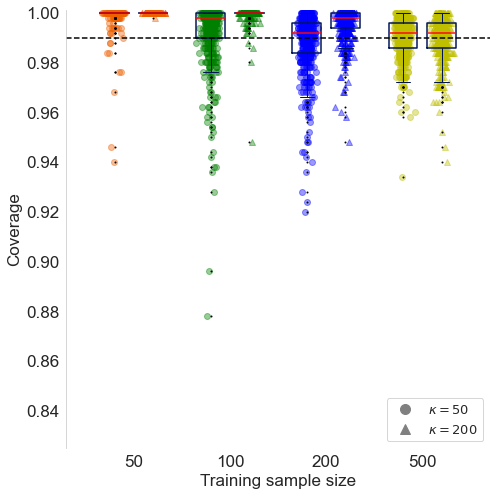

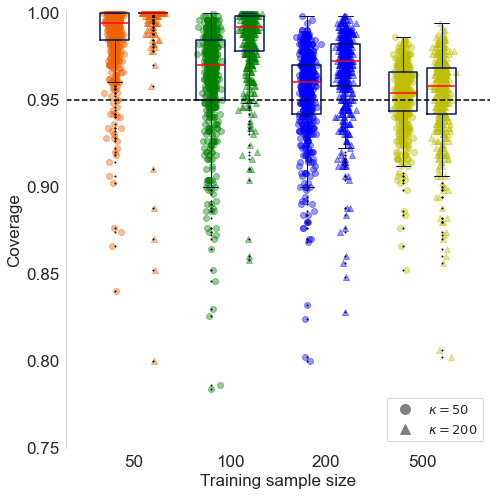

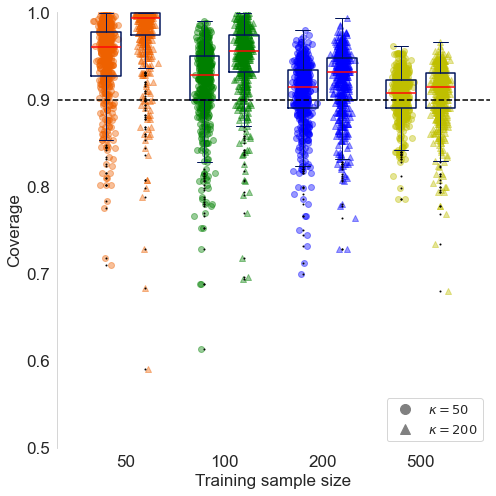

In [82]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for kappa_50_data, kappa_200_data, alpha_level in zip(
    [iv_pb_coverage_df_kappa_50_alpha_01, iv_pb_coverage_df_kappa_50_alpha_05, iv_pb_coverage_df_kappa_50_alpha_1], 
    [iv_pb_coverage_df_kappa_200_alpha_01, iv_pb_coverage_df_kappa_200_alpha_05, iv_pb_coverage_df_kappa_200_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    kappa_50_boxplot_data = [kappa_50_data[kappa_50_data['train_size'] == size]['iv_cov'].values for size in train_sizes]
    kappa_200_boxplot_data = [kappa_200_data[kappa_200_data['train_size'] == size]['iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_kappa_50 = np.array(range(len(train_sizes))) - 0.2
    positions_kappa_200 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(kappa_50_boxplot_data, positions=positions_kappa_50, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(kappa_200_boxplot_data, positions=positions_kappa_200, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_kappa_50 = ['#ee6100', 'g', 'b', 'y']
    palette_kappa_200 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_kappa_50 = np.random.normal(positions_kappa_50[i], 0.04, len(kappa_50_boxplot_data[i]))
        xs_kappa_200 = np.random.normal(positions_kappa_200[i], 0.04, len(kappa_200_boxplot_data[i]))

        ax.scatter(xs_kappa_50, kappa_50_boxplot_data[i], alpha=0.4, color=palette_kappa_50[i], label='Prediction balls')
        ax.scatter(xs_kappa_200, kappa_200_boxplot_data[i], alpha=0.4, color=palette_kappa_200[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$\kappa = 50$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$\kappa = 200$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_sphere/pb_sphere_kappa_50_200_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

# PDP to understand results Types III and IV

In [478]:
# Train forest
import pickle
from sklearn.metrics import make_scorer
from pyfrechet.metrics import mse
import sys, os
sys.path.append(os.getcwd())
import joblib
from joblib import Parallel, delayed
from pyfrechet.metric_spaces import MetricData, Sphere
from pyfrechet.regression.bagged_regressor import BaggedRegressor
from pyfrechet.regression.trees import Tree
from pyfrechet.metrics import mse
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
import base64
from scipy.stats import vonmises_fisher, vonmises_line

np.random.seed(1000)
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

sign_level = np.array([0.01, 0.05, 0.1])
param_grid = {
    'estimator__min_split_size': [1, 5, 10]
}

# Custom scorer (negative mean squared error)
neg_mse = make_scorer(mse, greater_is_better=False)

base = Tree(split_type='2means', mtry=None, impurity_method='cart')
base_forest = BaggedRegressor(estimator=base, n_estimators=200, bootstrap_fraction=1, bootstrap_replace=True, n_jobs=-1)

M = Sphere(2)

def tune_forest(X, y, forest = base_forest, param_grid=param_grid):
    """ Perform hyperparameter tuning using GridSearchCV. """
    tuned_forest = GridSearchCV(estimator = forest, param_grid=param_grid, scoring=neg_mse, cv=5, n_jobs=-1, verbose=0)
    tuned_forest.fit(X, y)
    return tuned_forest.best_estimator_

In [532]:
theta_array = np.linspace(-np.pi, np.pi, 1000)
sphere_values = m_0(theta_array, mu)

theta_q_5 = vonmises_line.ppf(0.05, loc=0, kappa=1)
theta_q_15 = vonmises_line.ppf(0.15, loc=0, kappa=1)
theta_q_25 = vonmises_line.ppf(0.25, loc=0, kappa=1)
theta_q_75 = vonmises_line.ppf(0.75, loc=0, kappa=1)
theta_q_85 = vonmises_line.ppf(0.85, loc=0, kappa=1)
theta_q_95 = vonmises_line.ppf(0.95, loc=0, kappa=1)

# select the values of forest_oob_errors_sorted that correspond to the predictors on the left of the 0.1 quantile
extreme_theta_quantile_5 = np.logical_or(theta_array < theta_q_5, theta_array > theta_q_95)
extreme_theta_quantile_15 = np.logical_or(theta_array < theta_q_15, theta_array > theta_q_85)
extreme_theta_quantile_25 = np.logical_or(theta_array < theta_q_25, theta_array > theta_q_75)

# select the values of forest_oob_errors_sorted that correspond to the predictors between the 0.1 and the 0.9 quantile
middle_theta_quantile_5 = np.logical_and(theta_array > theta_q_5, theta_array < theta_q_95)
middle_theta_quantile_15 = np.logical_and(theta_array > theta_q_15, theta_array < theta_q_85)
middle_theta_quantile_25 = np.logical_and(theta_array > theta_q_25, theta_array < theta_q_75)

assert(np.allclose(theta_q_5, -theta_q_95))
assert(np.allclose(theta_q_15, -theta_q_85))
assert(np.allclose(theta_q_25, -theta_q_75))

In [495]:
# Initialize dictionaries with empty lists
extreme_diccionario_5 = {
    'kappa_50': {'50': [], '100': [], '200': [], '500': []},
    'kappa_200': {'50': [], '100': [], '200': [], '500': []}
}
extreme_diccionario_15 = {
    'kappa_50': {'50': [], '100': [], '200': [], '500': []},
    'kappa_200': {'50': [], '100': [], '200': [], '500': []}
}
extreme_diccionario_25 = {
    'kappa_50': {'50': [], '100': [], '200': [], '500': []},
    'kappa_200': {'50': [], '100': [], '200': [], '500': []}
}
middle_diccionario_5 = {
    'kappa_50': {'50': [], '100': [], '200': [], '500': []},
    'kappa_200': {'50': [], '100': [], '200': [], '500': []}
}
middle_diccionario_15 = {
    'kappa_50': {'50': [], '100': [], '200': [], '500': []},
    'kappa_200': {'50': [], '100': [], '200': [], '500': []}
}
middle_diccionario_25 = {
    'kappa_50': {'50': [], '100': [], '200': [], '500': []},
    'kappa_200': {'50': [], '100': [], '200': [], '500': []}
}

# Process files
for file in os.listdir('/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_sphere/data/'):
    if file.endswith('.pkl'):
        infile = open('/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_sphere/data/' + file, 'rb')
        sample = pickle.load(infile)
        infile.close()

        # Extract kappa and N
        kappa = int(file.split('_')[3][5:])  # Extract integer value of kappa
        N = int(file.split('_')[2][1:])  # Extract integer value of N

        # Convert to dictionary key format
        kappa_key = f'kappa_{kappa}'
        N_key = str(N)

        # Compute errors
        X = np.c_[sample['theta']]
        y = MetricData(M, sample['Y'].reshape(-1, 3))

        forest = tune_forest(X, y, base_forest, param_grid)
        errors = M.d(MetricData(M, sphere_values), forest.predict(theta_array.reshape(-1, 1)))

        forest_errors_extreme_5 = errors[extreme_theta_quantile_5].mean()
        forest_errors_extreme_15 = errors[extreme_theta_quantile_15].mean()
        forest_errors_extreme_25 = errors[extreme_theta_quantile_25].mean()

        forest_errors_middle_5 = errors[middle_theta_quantile_5].mean()
        forest_errors_middle_15 = errors[middle_theta_quantile_15].mean()
        forest_errors_middle_25 = errors[middle_theta_quantile_25].mean()

        middle_diccionario_5[kappa_key][N_key].append(forest_errors_middle_5)
        middle_diccionario_15[kappa_key][N_key].append(forest_errors_middle_15)
        middle_diccionario_25[kappa_key][N_key].append(forest_errors_middle_25)

        extreme_diccionario_5[kappa_key][N_key].append(forest_errors_extreme_5)
        extreme_diccionario_15[kappa_key][N_key].append(forest_errors_extreme_15)
        extreme_diccionario_25[kappa_key][N_key].append(forest_errors_extreme_25)

INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


KeyboardInterrupt: 

In [531]:
def format_cell(mean, std):
    return f"{100 * mean:.2f} ({100 * std:.2f})"

# Prepare data for the DataFrame
rows = []
index = []

for kappa in [50, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        
        # Compute means and standard deviations for middle errors
        means_m = [
            np.mean(middle_diccionario_5[f'kappa_{kappa}'][str(N)]),
            np.mean(middle_diccionario_15[f'kappa_{kappa}'][str(N)]),
            np.mean(middle_diccionario_25[f'kappa_{kappa}'][str(N)])
        ]
        stds_m = [
            np.std(middle_diccionario_5[f'kappa_{kappa}'][str(N)]),
            np.std(middle_diccionario_15[f'kappa_{kappa}'][str(N)]),
            np.std(middle_diccionario_25[f'kappa_{kappa}'][str(N)])
        ]
        
        # Compute means and standard deviations for extreme errors
        means_e = [
            np.mean(extreme_diccionario_5[f'kappa_{kappa}'][str(N)]),
            np.mean(extreme_diccionario_15[f'kappa_{kappa}'][str(N)]),
            np.mean(extreme_diccionario_25[f'kappa_{kappa}'][str(N)])
        ]
        stds_e = [
            np.std(extreme_diccionario_5[f'kappa_{kappa}'][str(N)]),
            np.std(extreme_diccionario_15[f'kappa_{kappa}'][str(N)]),
            np.std(extreme_diccionario_25[f'kappa_{kappa}'][str(N)])
        ]
        
        # Format the values for the table
        formatted_values = [format_cell(means_m[i], stds_m[i]) for i in range(3)] + \
                           [format_cell(means_e[i], stds_e[i]) for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["m_5", "m_15", "m_25", "e_5", "e_15", "e_25"]],
    names=["Metric"]
)

# Create the DataFrame
df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Convert to LaTeX
latex = df.to_latex(index=True, multirow=True, multicolumn=True, 
                     multicolumn_format='c', bold_rows=True, 
                     float_format="%.3f", caption='Error Table', 
                     label='tab:error_table')

print(latex)

\begin{table}
\caption{Error Table}
\label{tab:error_table}
\begin{tabular}{llllllll}
\toprule
 & Metric & ('m_5',) & ('m_15',) & ('m_25',) & ('e_5',) & ('e_15',) & ('e_25',) \\
kappa & N &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{50}} & \textbf{50} & 12.30 (2.46) & 9.10 (1.71) & 8.37 (1.78) & 41.98 (18.13) & 29.59 (10.06) & 25.59 (7.98) \\
\textbf{} & \textbf{100} & 9.08 (1.30) & 7.78 (0.94) & 7.64 (1.02) & 21.85 (9.04) & 16.47 (4.88) & 14.71 (3.91) \\
\textbf{} & \textbf{200} & 7.85 (0.71) & 7.47 (0.73) & 7.40 (0.86) & 13.00 (2.94) & 10.73 (1.71) & 10.08 (1.40) \\
\textbf{} & \textbf{500} & 5.35 (0.85) & 4.87 (0.88) & 4.80 (0.93) & 10.58 (1.97) & 8.33 (1.02) & 7.64 (0.85) \\
\cline{1-8}
\multirow[t]{4}{*}{\textbf{200}} & \textbf{50} & 9.35 (2.31) & 5.87 (1.10) & 5.37 (1.17) & 42.88 (18.60) & 28.78 (9.87) & 24.20 (7.83) \\
\textbf{} & \textbf{100} & 5.94 (1.09) & 4.31 (0.53) & 4.11 (0.59) & 20.34 (8.22) & 14.38 (4.26) & 12.36 (3.38) \\
\textbf{} & \textbf{200} & 4.42 (0.

In [439]:
# Train forest
filename2 = '/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_sphere/data/sphere_samp3_N100_kappa200_block_1.pkl'

infile2 = open(filename2, 'rb')
sample2 = pickle.load(infile2)
infile2.close()

X2 = np.c_[sample2['theta']]
y2 = MetricData(M, sample2['Y'].reshape(-1, 3))
kappa = 200

# Perform hyperparameter tuning
forest2 = tune_forest(X2, y2, base_forest, param_grid)


INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


In [460]:
theta_array = np.linspace(-np.pi, np.pi, 1000)
sphere_values = m_0(theta_array, mu)
errors = M.d(MetricData(M,sphere_values), forest.predict(theta_array.reshape(-1,1)))
errors2 = M.d(MetricData(M,sphere_values), forest2.predict(theta_array.reshape(-1,1)))
theta_q_5 = vonmises_line.ppf(0.05, loc=0, kappa=1)
theta_q_15 = vonmises_line.ppf(0.15, loc=0, kappa=1)
theta_q_25 = vonmises_line.ppf(0.25, loc=0, kappa=1)
theta_q_75 = vonmises_line.ppf(0.75, loc=0, kappa=1)
theta_q_85 = vonmises_line.ppf(0.85, loc=0, kappa=1)
theta_q_95 = vonmises_line.ppf(0.95, loc=0, kappa=1)

assert(np.allclose(theta_q_5, -theta_q_95))
assert(np.allclose(theta_q_15, -theta_q_85))
assert(np.allclose(theta_q_25, -theta_q_75))

In [461]:
# select the values of forest_oob_errors_sorted that correspond to the predictors on the left of the 0.1 quantile
extreme_theta_quantile_5 = np.logical_or(theta_array < theta_q_5, theta_array > theta_q_95)
extreme_theta_quantile_15 = np.logical_or(theta_array < theta_q_15, theta_array > theta_q_85)
extreme_theta_quantile_25 = np.logical_or(theta_array < theta_q_25, theta_array > theta_q_75)

# select the values of forest_oob_errors_sorted that correspond to the predictors between the 0.1 and the 0.9 quantile
middle_theta_quantile_5 = np.logical_and(theta_array > theta_q_5, theta_array < theta_q_95)
middle_theta_quantile_15 = np.logical_and(theta_array > theta_q_15, theta_array < theta_q_85)
middle_theta_quantile_25 = np.logical_and(theta_array > theta_q_25, theta_array < theta_q_75)

forest_errors_extreme_5 = errors[extreme_theta_quantile_5]
forest_errors_extreme_15 = errors[extreme_theta_quantile_15]
forest_errors_extreme_25 = errors[extreme_theta_quantile_25]

forest_errors_middle_5 = errors[middle_theta_quantile_5]  
forest_errors_middle_15 = errors[middle_theta_quantile_15]
forest_errors_middle_25 = errors[middle_theta_quantile_25]

forest_errors_extreme_5_2 = errors2[extreme_theta_quantile_5]
forest_errors_extreme_15_2 = errors2[extreme_theta_quantile_15]
forest_errors_extreme_25_2 = errors2[extreme_theta_quantile_25]

forest_errors_middle_5_2 = errors2[middle_theta_quantile_5]
forest_errors_middle_15_2 = errors2[middle_theta_quantile_15]
forest_errors_middle_25_2 = errors2[middle_theta_quantile_25]

In [464]:
print('extremes', forest_errors_extreme_5.mean())
print('middle', forest_errors_middle_5.mean())

extremes 0.2342455949628613
middle 0.07632502875719796


In [465]:
print('extremes', forest_errors_extreme_5_2.mean())
print('middle', forest_errors_middle_5_2.mean())

extremes 0.2958947914071754
middle 0.04435299048512225


In [451]:
print(forest_errors_extreme_10_2.mean()/forest_errors_extreme_10.mean())
forest_errors_middle_10_2.mean()/forest_errors_middle_10.mean()

1.1401410575942938


0.5543077165593393

In [452]:
print(forest_errors_extreme_25_2.mean()/forest_errors_extreme_25.mean())
forest_errors_middle_25_2.mean()/forest_errors_middle_25.mean()

1.055864061189095


0.45638914480140985

In [253]:
# select the values of forest_oob_errors_sorted that correspond to the predictors on the left of the 0.1 quantile
left_X_quantile = X_sorted.ravel() < X_quantiles[0]
forest_oob_errors_left = forest_oob_errors_sorted[left_X_quantile]
# count how many values are on the left of the 0.1 quantile
n_left = np.sum(left_X_quantile)

# select the values of forest_oob_errors_sorted that correspond to the predictors on the right of the 0.9 quantile
right_X_quantile = X_sorted.ravel() > X_quantiles[1]
forest_oob_errors_right = forest_oob_errors_sorted[right_X_quantile]
# count how many values are on the right of the 0.9 quantile
n_right = np.sum(right_X_quantile)

# select the values of forest_oob_errors_sorted that correspond to the predictors between the 0.1 and the 0.9 quantile
middle_X_quantile = np.logical_and(X_sorted.ravel() > X_quantiles[0], X_sorted.ravel() < X_quantiles[1])
forest_oob_errors_middle = forest_oob_errors_sorted[middle_X_quantile]
# count how many values are between the 0.1 and the 0.9 quantile
n_middle = np.sum(middle_X_quantile)

In [176]:
print('left', forest_oob_errors_left.mean())
print('count left', n_left)
print('right', forest_oob_errors_right.mean())
print('count right', n_right)
print('middle', forest_oob_errors_middle.mean())
print('count middle', n_middle)

left 0.22282276543782742
count left 10
right 0.15722342311229592
count right 10
middle 0.10957356916742686
count middle 80


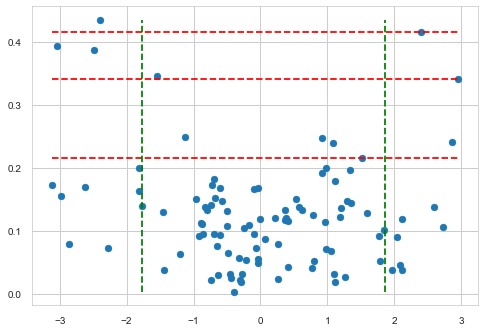

In [153]:
plt.scatter(X_sorted, forest_oob_errors_sorted)
plt.hlines(y=oob_quantile, xmin=X_sorted.min(), xmax=X_sorted.max(), colors='red', linestyles= 'dashed')
plt.vlines(x=quantiles, ymin=forest_oob_errors_sorted.min(), ymax=forest_oob_errors_sorted.max(), colors='green', linestyles= 'dashed')

In [320]:
X_q_10 = vonmises_line.ppf(0.1, loc=0, kappa=1)
X_q_90 = vonmises_line.ppf(0.9, loc=0, kappa=1)
dist_q_10 = M.d(m_0(theta=0, mu=mu), m_0(theta = X_q_90, mu = mu))
dist_q_90 = M.d(m_0(theta=0, mu=mu), m_0(theta = X_q_10, mu = mu))
assert(np.allclose(dist_q_10, dist_q_90))

# create an array 100*3 which contains "m_0(theta=0, mu=mu)" in each row
m = np.repeat(np.array([m_0(theta=0, mu=mu)]), 100, axis=0)
m = m.reshape(100,3)

distances_m_y = M.d(MetricData(M,m), y_sorted)
np.sum(distances_m_y >= dist_q_10)

26

In [172]:
# select the values of forest_oob_errors_sorted that correspond to the predictors on the left of the 0.1 quantile
left_X_quantile2 = X_sorted2.ravel() < X_quantiles2[0]
forest_oob_errors_left2 = forest_oob_errors_sorted2[left_X_quantile2]

# select the values of forest_oob_errors_sorted that correspond to the predictors on the right of the 0.9 quantile
right_X_quantile2 = X_sorted2.ravel() > X_quantiles2[1]
forest_oob_errors_right2 = forest_oob_errors_sorted2[right_X_quantile2]

# select the values of forest_oob_errors_sorted that correspond to the predictors between the 0.1 and the 0.9 quantile
middle_X_quantile2 = np.logical_and(X_sorted2.ravel() > X_quantiles2[0], X_sorted2.ravel() < X_quantiles2[1])
forest_oob_errors_middle2 = forest_oob_errors_sorted2[middle_X_quantile2]

In [174]:
print('left', forest_oob_errors_left2.mean())
print('right', forest_oob_errors_right2.mean())
print('middle', forest_oob_errors_middle2.mean())

left 0.20635036020824454
right 0.15691048367682775
middle 0.1087978074993915


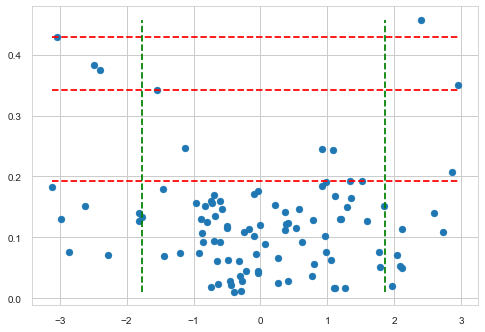

In [158]:
plt.scatter(X_sorted2, forest_oob_errors_sorted2)
plt.hlines(y=oob_quantile2, xmin=X_sorted2.min(), xmax=X_sorted2.max(), colors='red', linestyles= 'dashed')
plt.vlines(x=quantiles2, ymin=forest_oob_errors_sorted2.min(), ymax=forest_oob_errors_sorted2.max(), colors='green', linestyles= 'dashed')

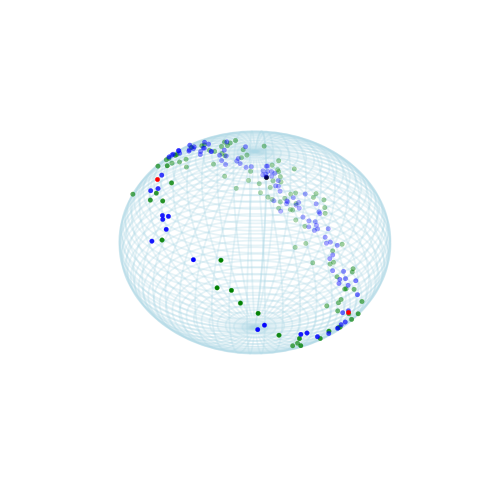

In [366]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises_fisher

# Create directory for saving samples
save_folder = os.path.join(os.getcwd(), 'simulations_sphere', 'data')
os.makedirs(save_folder, exist_ok=True)

np.random.seed(1000)

# Plotting the unit sphere
fig=plt.figure()
fig.set_size_inches(7, 7)
ax=plt.axes(projection='3d', computed_zorder=False)

# Create a mesh grid for the unit sphere
u = np.linspace(0, np.pi, 100)
v = np.linspace(0, 2 * np.pi, 100)
u, v = np.meshgrid(u, v)

x_sphere = np.sin(u) * np.cos(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(u)

ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, zorder = 0)

ax.scatter(sample['Y'][:,0,:][:,0], sample['Y'][:,0,:][:,1], sample['Y'][:,0,:][:,2], color='green', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)
ax.scatter(sample2['Y'][:,0,:][:,0], sample2['Y'][:,0,:][:,1], sample2['Y'][:,0,:][:,2], color='blue', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)

p1 = m_0(theta=0, mu=mu)[0]
p2 = m_0(theta = X_q_90, mu = mu)[0]
p3 = m_0(theta = X_q_10, mu = mu)[0]
ax.scatter( p1[0], p1[1], p1[2], color = 'black', zorder = 0)
ax.scatter( p2[0], p2[1], p2[2], color = 'red', zorder = 1)
ax.scatter( p3[0], p3[1], p3[2], color = 'red', zorder = 1)
# ax.scatter(preds[:,0], preds[:,1], preds[:,2], color = 'red', zorder = 1)
    
ax.view_init(elev=30, azim=185)  # Adjust view angle
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()
# fig.subplots_adjust(top=1, bottom=0, left=-1, right=1)
# fig.savefig(os.getcwd() + '/simulations_H2/dibujo/sphere_curv_one.pdf', bbox_inches='tight', format='pdf', transparent=True)
plt.show()

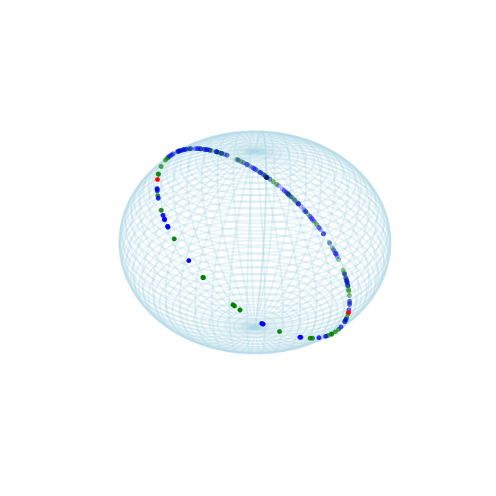

In [365]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises_fisher

# Create directory for saving samples
save_folder = os.path.join(os.getcwd(), 'simulations_sphere', 'data')
os.makedirs(save_folder, exist_ok=True)

np.random.seed(1000)

# Plotting the unit sphere
fig=plt.figure()
fig.set_size_inches(7, 7)
ax=plt.axes(projection='3d', computed_zorder=False)

# Create a mesh grid for the unit sphere
u = np.linspace(0, np.pi, 100)
v = np.linspace(0, 2 * np.pi, 100)
u, v = np.meshgrid(u, v)

x_sphere = np.sin(u) * np.cos(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(u)

ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, zorder = 0)

theoretical = m_0(theta = sample['theta'], mu = mu)
theoretical2 = m_0(theta = sample2['theta'], mu = mu)
ax.scatter(theoretical[:,0], theoretical[:,1], theoretical[:,2], color='green', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)
ax.scatter(theoretical2[:,0], theoretical2[:,1], theoretical2[:,2], color='blue', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)
#ax.scatter(sample['Y'][:,0,:][:,0], sample['Y'][:,0,:][:,1], sample['Y'][:,0,:][:,2], color='green', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)
#ax.scatter(sample2['Y'][:,0,:][:,0], sample2['Y'][:,0,:][:,1], sample2['Y'][:,0,:][:,2], color='blue', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)

p1 = m_0(theta=0, mu=mu)[0]
p2 = m_0(theta = X_q_90, mu = mu)[0]
p3 = m_0(theta = X_q_10, mu = mu)[0]
ax.scatter( p1[0], p1[1], p1[2], color = 'black', zorder = 0)
ax.scatter( p2[0], p2[1], p2[2], color = 'red', zorder = 1)
ax.scatter( p3[0], p3[1], p3[2], color = 'red', zorder = 1)
# ax.scatter(preds[:,0], preds[:,1], preds[:,2], color = 'red', zorder = 1)
    
ax.view_init(elev=30, azim=185)  # Adjust view angle
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()
# fig.subplots_adjust(top=1, bottom=0, left=-1, right=1)
# fig.savefig(os.getcwd() + '/simulations_H2/dibujo/sphere_curv_one.pdf', bbox_inches='tight', format='pdf', transparent=True)
plt.show()

In [353]:
theoretical = m_0(theta = sample['theta'], mu = mu)
theoretical

array([[-0.09165933, -0.70413016, -0.70413016],
       [ 0.98462232,  0.12352913,  0.12352913],
       [-0.71405265,  0.4950398 ,  0.4950398 ],
       [ 0.46887687,  0.62456164,  0.62456164],
       [ 0.49946769, -0.6125896 , -0.6125896 ],
       [ 0.39542628, -0.64947596, -0.64947596],
       [ 0.42188625, -0.64109749, -0.64109749],
       [ 0.70386055, -0.50228494, -0.50228494],
       [ 0.63053285,  0.54882981,  0.54882981],
       [ 0.83760222,  0.38627874,  0.38627874],
       [ 0.88508468, -0.32910873, -0.32910873],
       [ 0.99675661, -0.05690459, -0.05690459],
       [ 0.92574265, -0.26739536, -0.26739536],
       [ 0.02649125,  0.70685862,  0.70685862],
       [ 0.58992216,  0.57096053,  0.57096053],
       [ 0.94673268, -0.22770292, -0.22770292],
       [ 0.95112725,  0.21835402,  0.21835402],
       [-0.94814426,  0.22474705,  0.22474705],
       [-0.54876944, -0.5911227 , -0.5911227 ],
       [ 0.42662884,  0.63952632,  0.63952632],
       [ 0.66071196,  0.53078231,  0.530

In [347]:
p1[0]

array([1., 0., 0.])

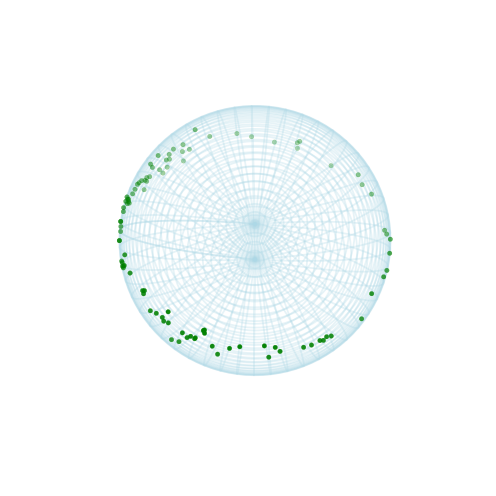

In [185]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises_fisher

# Create directory for saving samples
save_folder = os.path.join(os.getcwd(), 'simulations_sphere', 'data')
os.makedirs(save_folder, exist_ok=True)

np.random.seed(1000)

# Plotting the unit sphere
fig=plt.figure()
fig.set_size_inches(7, 7)
ax=plt.axes(projection='3d', computed_zorder=False)

# Create a mesh grid for the unit sphere
u = np.linspace(0, np.pi, 100)
v = np.linspace(0, 2 * np.pi, 100)
u, v = np.meshgrid(u, v)

x_sphere = np.sin(u) * np.cos(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(u)

ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, zorder = 0)

ax.scatter(sample2['Y'][:,0,:][:,0], sample2['Y'][:,0,:][:,1], sample2['Y'][:,0,:][:,2], color='green', label=r'$\boldsymbol{m}_0(\theta)$', zorder = 1)

# ax.scatter(preds[:,0], preds[:,1], preds[:,2], color = 'red', zorder = 1)
    
ax.view_init(elev=100, azim=95)  # Adjust view angle
ax.grid(False)
ax.set_axis_off()
fig.tight_layout()
# fig.subplots_adjust(top=1, bottom=0, left=-1, right=1)
# fig.savefig(os.getcwd() + '/simulations_H2/dibujo/sphere_curv_one.pdf', bbox_inches='tight', format='pdf', transparent=True)
plt.show()

In [125]:
MSE = M.d(preds, m_0(sample['theta'], mu=mu))**2

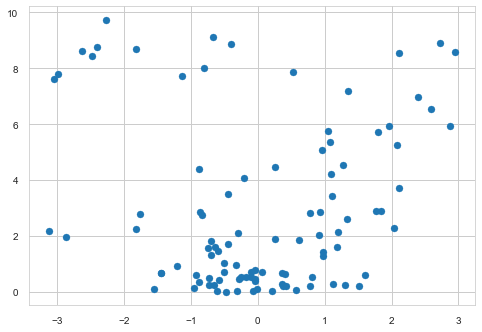

In [127]:
plt.scatter(sample['theta'], MSE)